<a href="https://colab.research.google.com/github/MNawfal24/PCVK_Ganjil_2026/blob/main/Week3_pcvdk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== SEL IDENTITAS =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Muhammad Nawfal Mawla Azhar'
NIM = '244107020174'

N = int(NIM[-3:])
PARAM = {
    'b' : (N % 61) + 20,
    'a' : round(1.0 + (N % 9) / 10, 1),
    'c' : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s: %s' % (k, v))
print('WAKTU :', waktu.strftime("%Y-%m-%d %H:%M:%S %Z"))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Muhammad Nawfal Mawla Azhar
NIM  : 244107020174 | N = 174
b     : 72
a     : 1.3
c     : 44
gamma : 0.4
bit   : 2
WAKTU : 2026-09-15 14:35:22 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : ad680f1c09f417d8


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


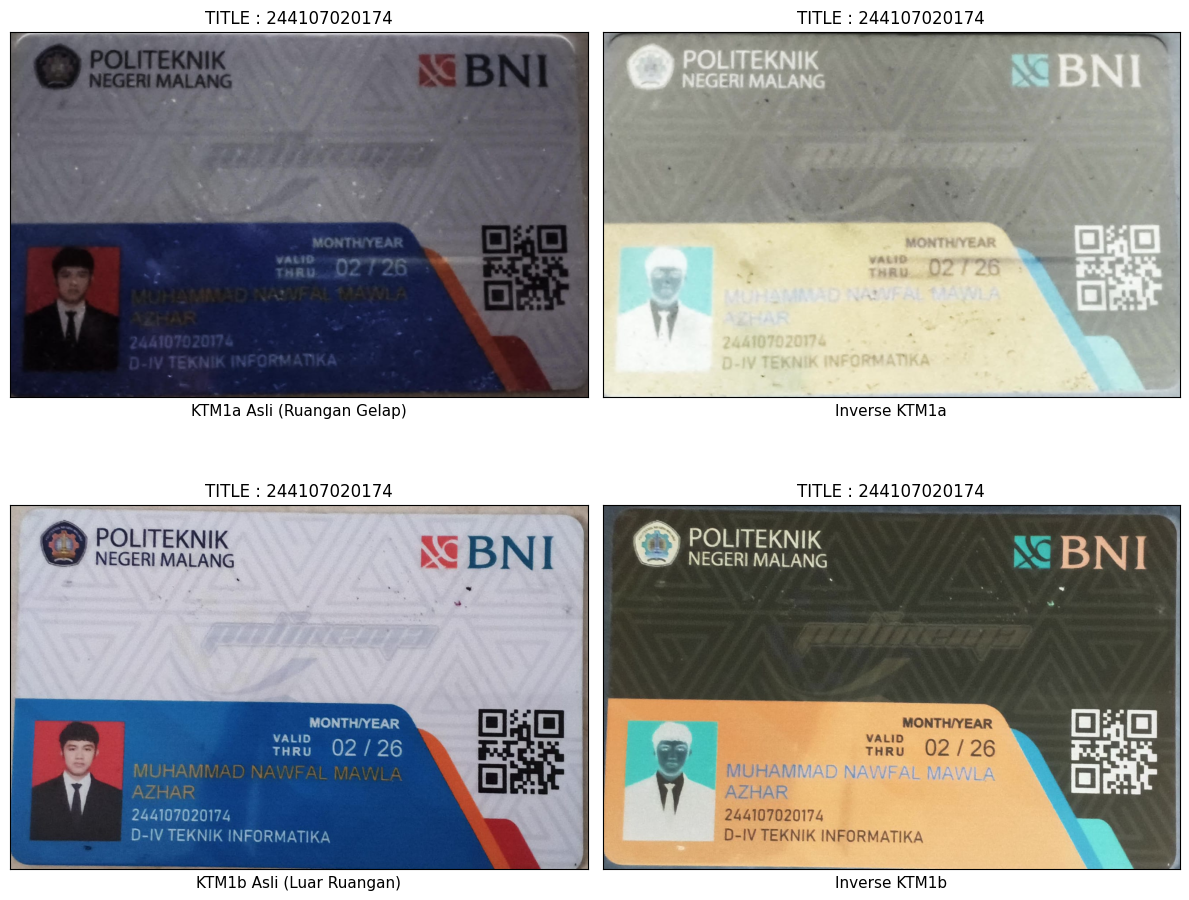

HASIL ANALISA TUGAS 1:
Mengapa hasil inverse dari citra gelap (KTM1a) justru terlihat pucat atau kelabu
dibandingkan hasil inverse citra terang (KTM1b)?

Jawaban:
1. Pada citra KTM1a yang gelap, nilai piksel aslinya banyak berkumpul di area
   angka rendah (misal: 30 - 80). Ketika di-inverse (255 - piksel), hasilnya akan
   berada di rentang angka tinggi (175 - 225) yang merepresentasikan warna putih
   atau abu-abu terang yang merata.
2. Karena kurangnya variasi gelap-terang (kontras) pada gambar aslinya, hasil
   inversenya pun menjadi sekadar hamparan warna terang yang minim tekstur,
   sehingga terlihat pucat (washed out).


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_ktm1a = base_path + 'KTM1_a.jpeg'
path_ktm1b = base_path + 'KTM1_b.jpeg'

img_ktm1a = cv.imread(path_ktm1a)
img_ktm1b = cv.imread(path_ktm1b)

#Konversi format BGR ke RGB untuk Matplotlib
img_ktm1a_rgb = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)
img_ktm1b_rgb = cv.cvtColor(img_ktm1b, cv.COLOR_BGR2RGB)

#Terapkan rumus Inverse Citra: g(x) = 255 - f(x)
inv_ktm1a = 255 - img_ktm1a_rgb
inv_ktm1b = 255 - img_ktm1b_rgb

#Tampilkan KTM1a (Gelap) dan Inversenya
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_ktm1a_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("KTM1a Asli (Ruangan Gelap)", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(2, 2, 2)
plt.imshow(inv_ktm1a)
plt.title(f"TITLE : {NIM}")
plt.xlabel("Inverse KTM1a", fontsize=11)
plt.xticks([]); plt.yticks([])

#Tampilkan KTM1b (Terang) dan Inversenya
plt.subplot(2, 2, 3)
plt.imshow(img_ktm1b_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("KTM1b Asli (Luar Ruangan)", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(2, 2, 4)
plt.imshow(inv_ktm1b)
plt.title(f"TITLE : {NIM}")
plt.xlabel("Inverse KTM1b", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

#Print Hasil Analisa
print("="*75)
print("HASIL ANALISA TUGAS 1:")
print("="*75)
print("Mengapa hasil inverse dari citra gelap (KTM1a) justru terlihat pucat atau kelabu")
print("dibandingkan hasil inverse citra terang (KTM1b)?")
print("\nJawaban:")
print("1. Pada citra KTM1a yang gelap, nilai piksel aslinya banyak berkumpul di area")
print("   angka rendah (misal: 30 - 80). Ketika di-inverse (255 - piksel), hasilnya akan")
print("   berada di rentang angka tinggi (175 - 225) yang merepresentasikan warna putih")
print("   atau abu-abu terang yang merata.")
print("2. Karena kurangnya variasi gelap-terang (kontras) pada gambar aslinya, hasil")
print("   inversenya pun menjadi sekadar hamparan warna terang yang minim tekstur,")
print("   sehingga terlihat pucat (washed out).")
print("="*75)

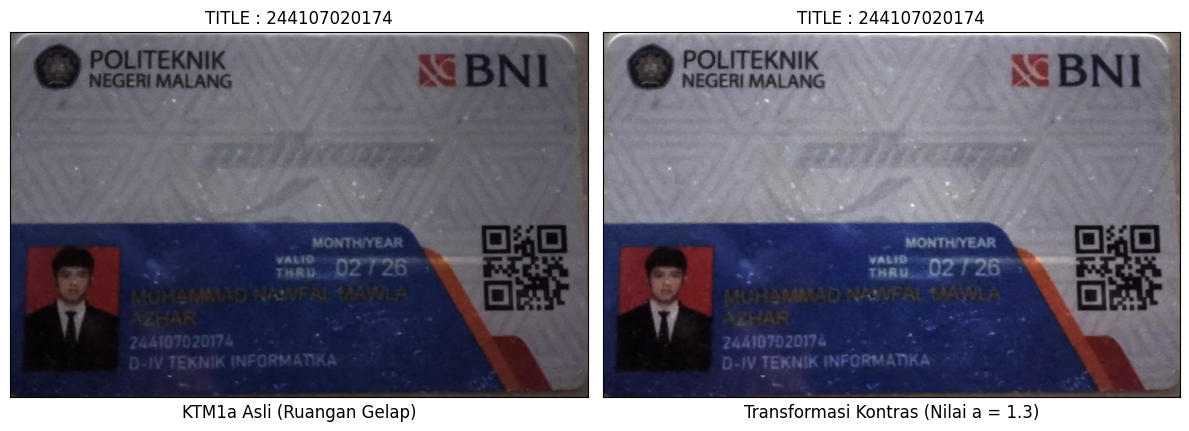

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_ktm1a = base_path + 'KTM1_a.jpeg'

#Konversi Gambar Ke RGB
img_ktm1a = cv.imread(path_ktm1a)
img_ktm1a_rgb = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)

#Mengambil parameter kontras 'a' dari Sel Identitas
a = PARAM['a']
b = 0 # Nilai kecerahan dibiarkan 0

#Operasi Transformasi Kontras: g(x,y) = a * f(x,y) + b
img_kontras = np.clip(img_ktm1a_rgb.astype(np.float32) * a + b, 0, 255).astype(np.uint8)

# Tampilkan gambar
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_ktm1a_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("KTM1a Asli (Ruangan Gelap)", fontsize=12)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(img_kontras)
plt.title(f"TITLE : {NIM}")
plt.xlabel(f"Transformasi Kontras (Nilai a = {a})", fontsize=12)
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

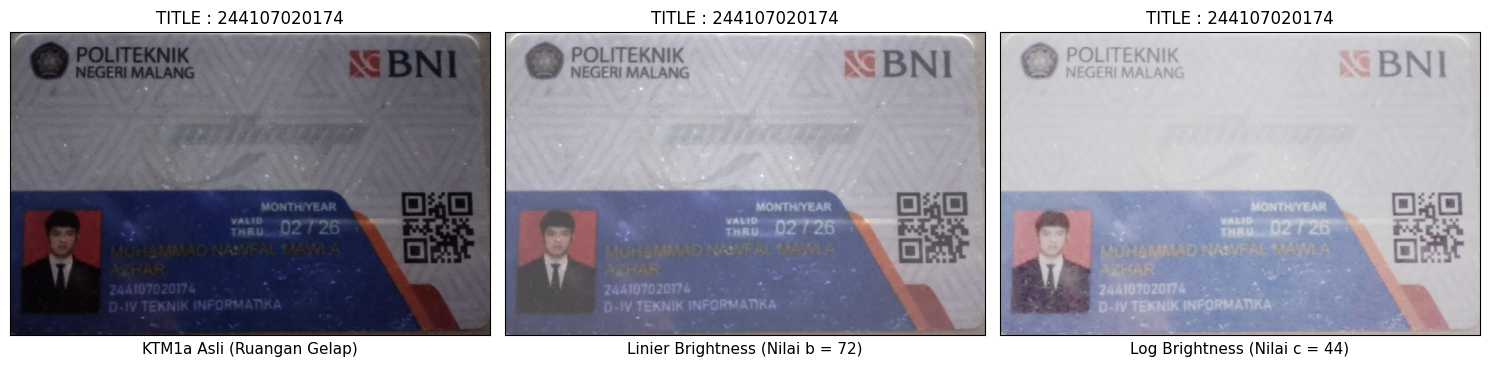

HASIL ANALISA TUGAS 3:
1. Metode yang membuat NIM lebih terbaca:
   Metode Transformasi Logarithmic Brightness membuat teks pada
   NIM kartu lebih terbaca dibandingkan Linier Brightness. Hal ini karena
   metode logaritma sangat baik dalam meningkatkan detail pada rentang piksel
   yang gelap tanpa langsung merusak area yang sudah terang.

2. Bagian yang menjadi putih penuh (clipping):
   - Linier Brightness: Area background yang aslinya agak terang akan mengalami
     clipping (mentok di 255) karena semua piksel ditambah nilainya secara merata.
   - Logarithmic Brightness: Area clipping lebih minim, detail gambar lebih
     terjaga. Namun jika nilai c terlalu besar, area paling terang akan tetap
     memutih penuh.


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_ktm1a = base_path + 'KTM1_a.jpeg'

# konversi ke RGB
img_ktm1a = cv.imread(path_ktm1a)
img_ktm1a_rgb = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)

# 3. Mengambil parameter b dan c dari Sel Identitas
b = PARAM['b']
c = PARAM['c']

#Operasi Linier Brightness: g(x,y) = f(x,y) + b
img_linier = np.clip(img_ktm1a_rgb.astype(np.float32) + b, 0, 255).astype(np.uint8)

#Operasi Logarithmic Brightness: s = c * log(1 + r)
img_log = np.clip(c * np.log(1 + img_ktm1a_rgb.astype(np.float32)), 0, 255).astype(np.uint8)

#Tampilkan gambar
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_ktm1a_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("KTM1a Asli (Ruangan Gelap)", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(img_linier)
plt.title(f"TITLE : {NIM}")
plt.xlabel(f"Linier Brightness (Nilai b = {b})", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(img_log)
plt.title(f"TITLE : {NIM}")
plt.xlabel(f"Log Brightness (Nilai c = {c})", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

# Hasil Analisa
print("="*75)
print("HASIL ANALISA TUGAS 3:")
print("="*75)
print("1. Metode yang membuat NIM lebih terbaca:")
print("   Metode Transformasi Logarithmic Brightness membuat teks pada")
print("   NIM kartu lebih terbaca dibandingkan Linier Brightness. Hal ini karena")
print("   metode logaritma sangat baik dalam meningkatkan detail pada rentang piksel")
print("   yang gelap tanpa langsung merusak area yang sudah terang.")
print("\n2. Bagian yang menjadi putih penuh (clipping):")
print("   - Linier Brightness: Area background yang aslinya agak terang akan mengalami")
print("     clipping (mentok di 255) karena semua piksel ditambah nilainya secara merata.")
print("   - Logarithmic Brightness: Area clipping lebih minim, detail gambar lebih")
print("     terjaga. Namun jika nilai c terlalu besar, area paling terang akan tetap Memutih Penuh")
print("="*75)

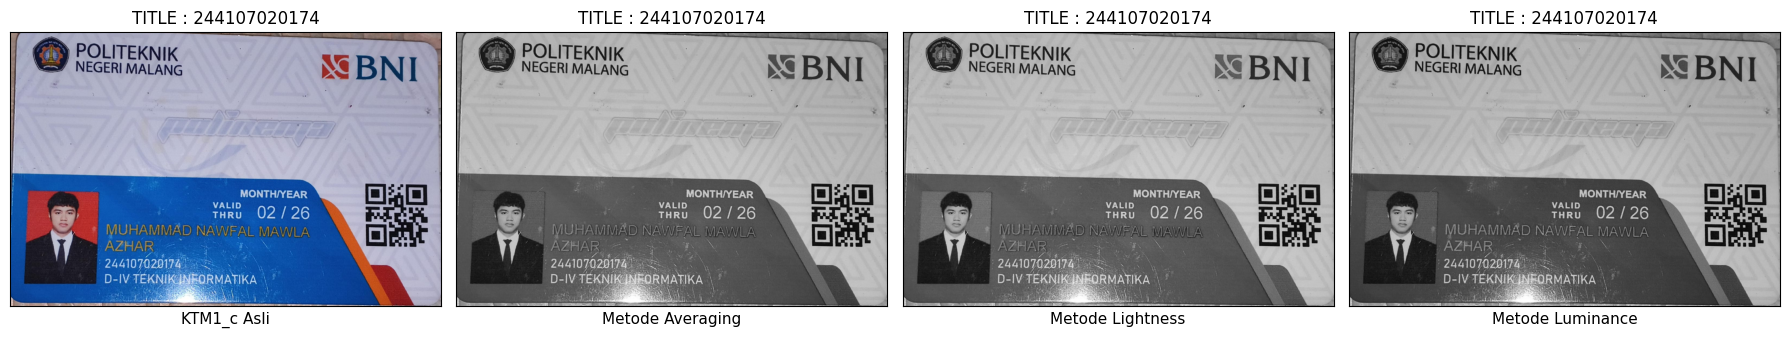

HASIL ANALISA TUGAS 4:
Metode Grayscale mana yang paling baik mempertahankan detail kontras?
Jawaban: Metode Luminance.
Alasan: Luminance memberikan bobot yang berbeda pada setiap warna (Hijau paling
tinggi, disusul Merah, lalu Biru paling rendah) sesuai dengan sensitivitas mata
manusia. Hasilnya, kontras antara warna gelap dan terang pada gambar asli bisa
diterjemahkan ke skala abu-abu dengan jauh lebih natural dibandingkan Averaging
yang hanya merata-rata secara buta.


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_ktm1c = base_path + 'KTM1_c.jpeg'

# konversi ke RGB
img_ktm1c = cv.imread(path_ktm1c)
img_ktm1c_rgb = cv.cvtColor(img_ktm1c, cv.COLOR_BGR2RGB)

# Ekstrak channel R, G, dan B lalu ubah ke float32 untuk perhitungan
R = img_ktm1c_rgb[:,:,0].astype(np.float32)
G = img_ktm1c_rgb[:,:,1].astype(np.float32)
B = img_ktm1c_rgb[:,:,2].astype(np.float32)

# Operasi Averaging: (R + G + B) / 3
gray_avg = np.mean(img_ktm1c_rgb, axis=2).astype(np.uint8)

# Operasi Lightness: (Max(R,G,B) + Min(R,G,B)) / 2
max_rgb = np.max(img_ktm1c_rgb, axis=2).astype(np.float32)
min_rgb = np.min(img_ktm1c_rgb, axis=2).astype(np.float32)
gray_light = ((max_rgb + min_rgb) / 2).astype(np.uint8)

# Operasi Luminance: 0.299*R + 0.587*G + 0.114*B
gray_lum = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

# Tampilkan keempat gambar secara berurutan
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_ktm1c_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("KTM1_c Asli", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 4, 2)
plt.imshow(gray_avg, cmap='gray')
plt.title(f"TITLE : {NIM}")
plt.xlabel("Metode Averaging", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 4, 3)
plt.imshow(gray_light, cmap='gray')
plt.title(f"TITLE : {NIM}")
plt.xlabel("Metode Lightness", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 4, 4)
plt.imshow(gray_lum, cmap='gray')
plt.title(f"TITLE : {NIM}")
plt.xlabel("Metode Luminance", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

# Print Analisa
print("="*75)
print("HASIL ANALISA TUGAS 4:")
print("="*75)
print("Metode Grayscale mana yang paling baik mempertahankan detail kontras?")
print("Jawaban: Metode Luminance.")
print("Alasan: Luminance memberikan bobot yang berbeda pada setiap warna (Hijau paling")
print("tinggi, disusul Merah, lalu Biru paling rendah) sesuai dengan sensitivitas mata")
print("manusia. Hasilnya, kontras antara warna gelap dan terang pada gambar asli bisa")
print("diterjemahkan ke skala abu-abu dengan jauh lebih natural dibandingkan Averaging")
print("yang hanya merata-rata secara buta.")
print("="*75)

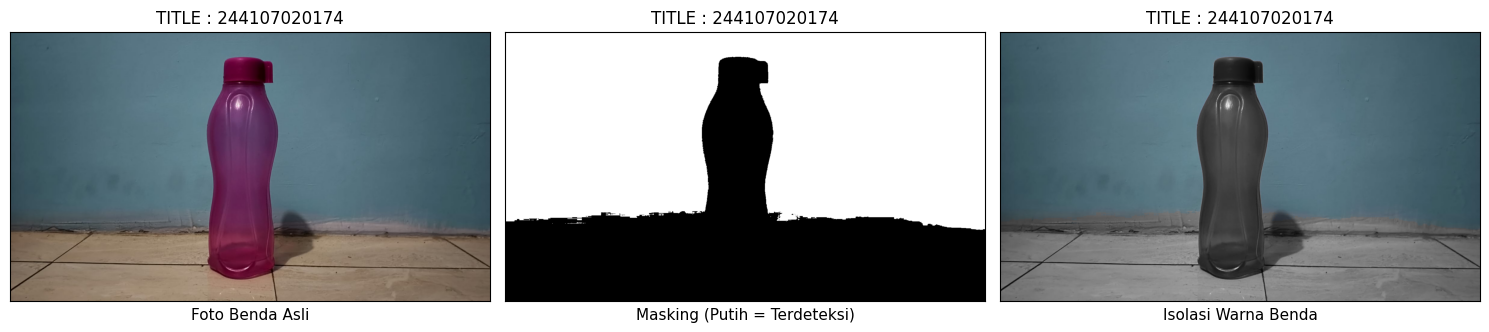

HASIL ANALISA TUGAS 5:
1. Rentang batas warna HSV yang dipakai: [90 50 50] hingga [130 255 255]
2. Jika rentang nilai diperlebar:
   Masking akan mendeteksi variasi warna yang terlalu luas. Akibatnya,
   objek atau latar belakang yang warnanya sedikit mirip akan ikut berwarna
   (gagal menjadi abu-abu/grayscale).
3. Jika rentang nilai dipersempit:
   Seleksi menjadi terlalu ketat. Area benda yang aslinya berwarna sama namun
   terkena pantulan cahaya terang atau bayangan gelap tidak akan terdeteksi
   dan justru ikut berubah menjadi abu-abu (bolong-bolong).


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_obj = base_path + 'Benda_Pribadi.jpeg'

img_obj = cv.imread(path_obj)
img_rgb = cv.cvtColor(img_obj, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_obj, cv.COLOR_BGR2HSV)

#Tentukan Rentang Warna HSV (Contoh: Warna Biru)
lower_color = np.array([90, 50, 50])
upper_color = np.array([130, 255, 255])

#Proses Masking dan Isolasi Benda (Foreground)
mask = cv.inRange(img_hsv, lower_color, upper_color)
color_part = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

#Proses Grayscale untuk Latar Belakang (Background)
img_gray = cv.cvtColor(img_obj, cv.COLOR_BGR2GRAY)
img_gray_3ch = cv.cvtColor(img_gray, cv.COLOR_GRAY2RGB)
mask_inv = cv.bitwise_not(mask)
gray_part = cv.bitwise_and(img_gray_3ch, img_gray_3ch, mask=mask_inv)

#Gabungkan Foreground Berwarna dan Background Grayscale
img_final = cv.add(color_part, gray_part)

#Tampilkan secara eksplisit
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("Foto Benda Asli", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title(f"TITLE : {NIM}")
plt.xlabel("Masking (Putih = Terdeteksi)", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(img_final)
plt.title(f"TITLE : {NIM}")
plt.xlabel("Isolasi Warna Benda", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

#Print Analisa
print("="*75)
print("HASIL ANALISA TUGAS 5:")
print("="*75)
print(f"1. Rentang batas warna HSV yang dipakai: {lower_color} hingga {upper_color}")
print("2. Jika rentang nilai diperlebar:")
print("   Masking akan mendeteksi variasi warna yang terlalu luas. Akibatnya,")
print("   objek atau latar belakang yang warnanya sedikit mirip akan ikut berwarna")
print("   (gagal menjadi abu-abu/grayscale).")
print("3. Jika rentang nilai dipersempit:")
print("   Seleksi menjadi terlalu ketat. Area benda yang aslinya berwarna sama namun")
print("   terkena pantulan cahaya terang atau bayangan gelap tidak akan terdeteksi")
print("   dan justru ikut berubah menjadi abu-abu (bolong-bolong).")
print("="*75)

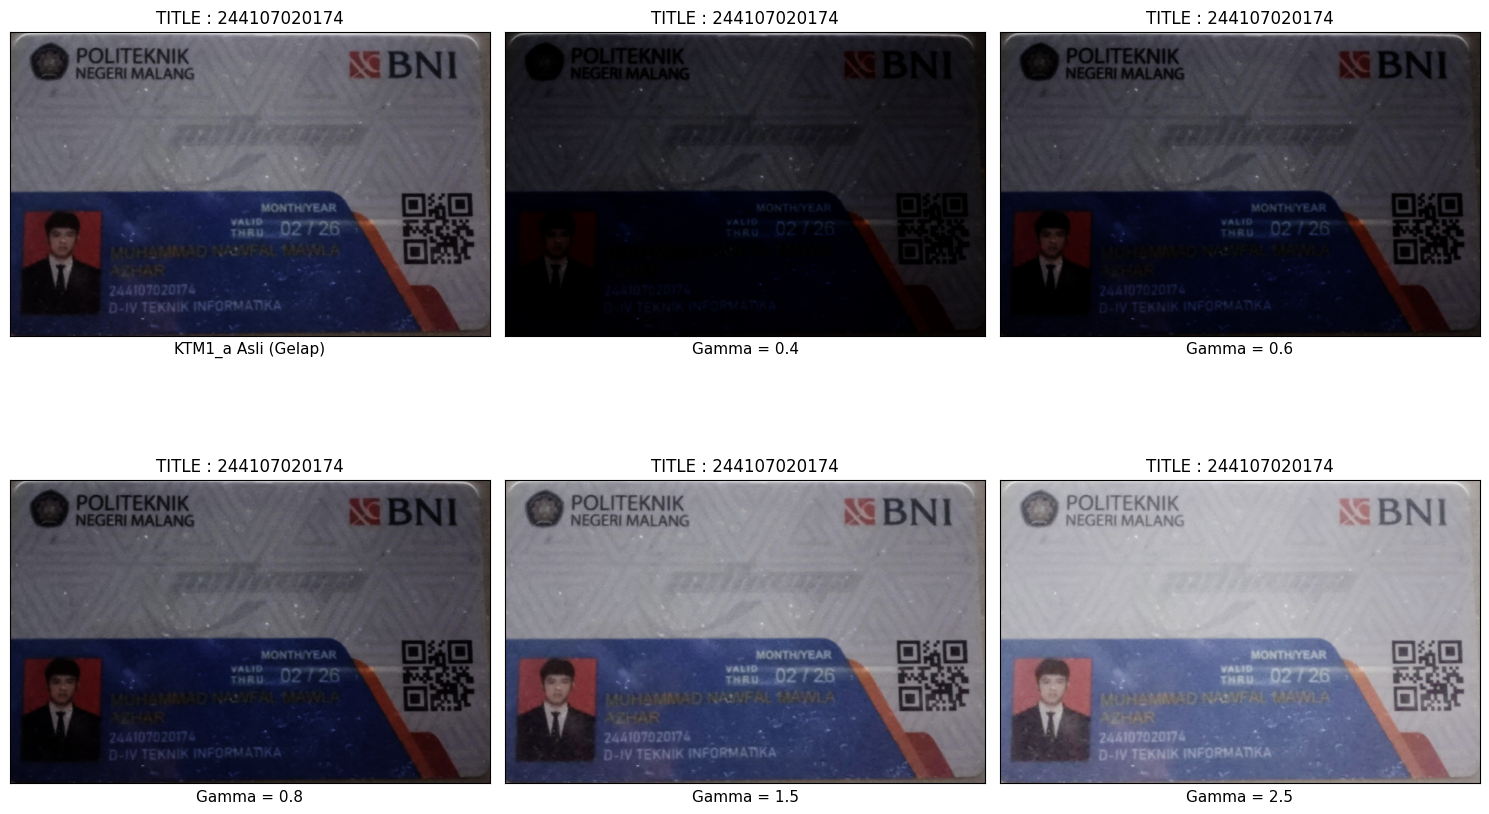

HASIL ANALISA TUGAS 6:
Mengapa nilai terbaik (paling jelas) untuk setiap mahasiswa berbeda-beda?

Jawaban:
Setiap foto memiliki profil histogram pencahayaan yang unik akibat:
- Kondisi pencahayaan ruangan asli (lux) yang berbeda saat foto diambil.
- Sensor dan pemrosesan auto-exposure dari kamera HP masing-masing mahasiswa.
Akibatnya, tingkat 'kegelapan' foto tidak ada yang sama persis, sehingga
membutuhkan derajat kelengkungan pencerahan (nilai Gamma) yang berbeda pula
untuk menarik piksel-piksel bayangan ke titik ideal tanpa membuatnya menyilaukan.


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_ktm1a = base_path + 'KTM1_a.jpeg'

img_ktm1a = cv.imread(path_ktm1a)
img_rgb = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)

#Ambil parameter Gamma dari NIM dan tentukan nilai uji lain
gamma_awal = PARAM['gamma']
daftar_gamma = [gamma_awal, 0.6, 0.8, 1.5, 2.5]

# Setup kanvas plot 2 baris 3 kolom
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("KTM1_a Asli (Gelap)", fontsize=11)
plt.xticks([]); plt.yticks([])

# Looping perhitungan Gamma
for i, g in enumerate(daftar_gamma):
    # Rumus = 255 * (I/255)^(1/gamma)
    inv_gamma = 1.0 / g
    img_gamma = np.clip(255.0 * np.power(img_rgb / 255.0, inv_gamma), 0, 255).astype(np.uint8)

    plt.subplot(2, 3, i + 2)
    plt.imshow(img_gamma)
    plt.title(f"TITLE : {NIM}")
    plt.xlabel(f"Gamma = {g}", fontsize=11)
    plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

#Print Analisa
print("="*75)
print("HASIL ANALISA TUGAS 6:")
print("="*75)
print("Mengapa nilai terbaik (paling jelas) untuk setiap mahasiswa berbeda-beda?")
print("\nJawaban:")
print("Setiap foto memiliki profil histogram pencahayaan yang unik akibat:")
print("- Kondisi pencahayaan ruangan asli (lux) yang berbeda saat foto diambil.")
print("- Sensor dan pemrosesan auto-exposure dari kamera HP masing-masing mahasiswa.")
print("Akibatnya, tingkat 'kegelapan' foto tidak ada yang sama persis, sehingga")
print("membutuhkan derajat kelengkungan pencerahan (nilai Gamma) yang berbeda pula")
print("untuk menarik piksel-piksel bayangan ke titik ideal tanpa membuatnya menyilaukan.")
print("="*75)

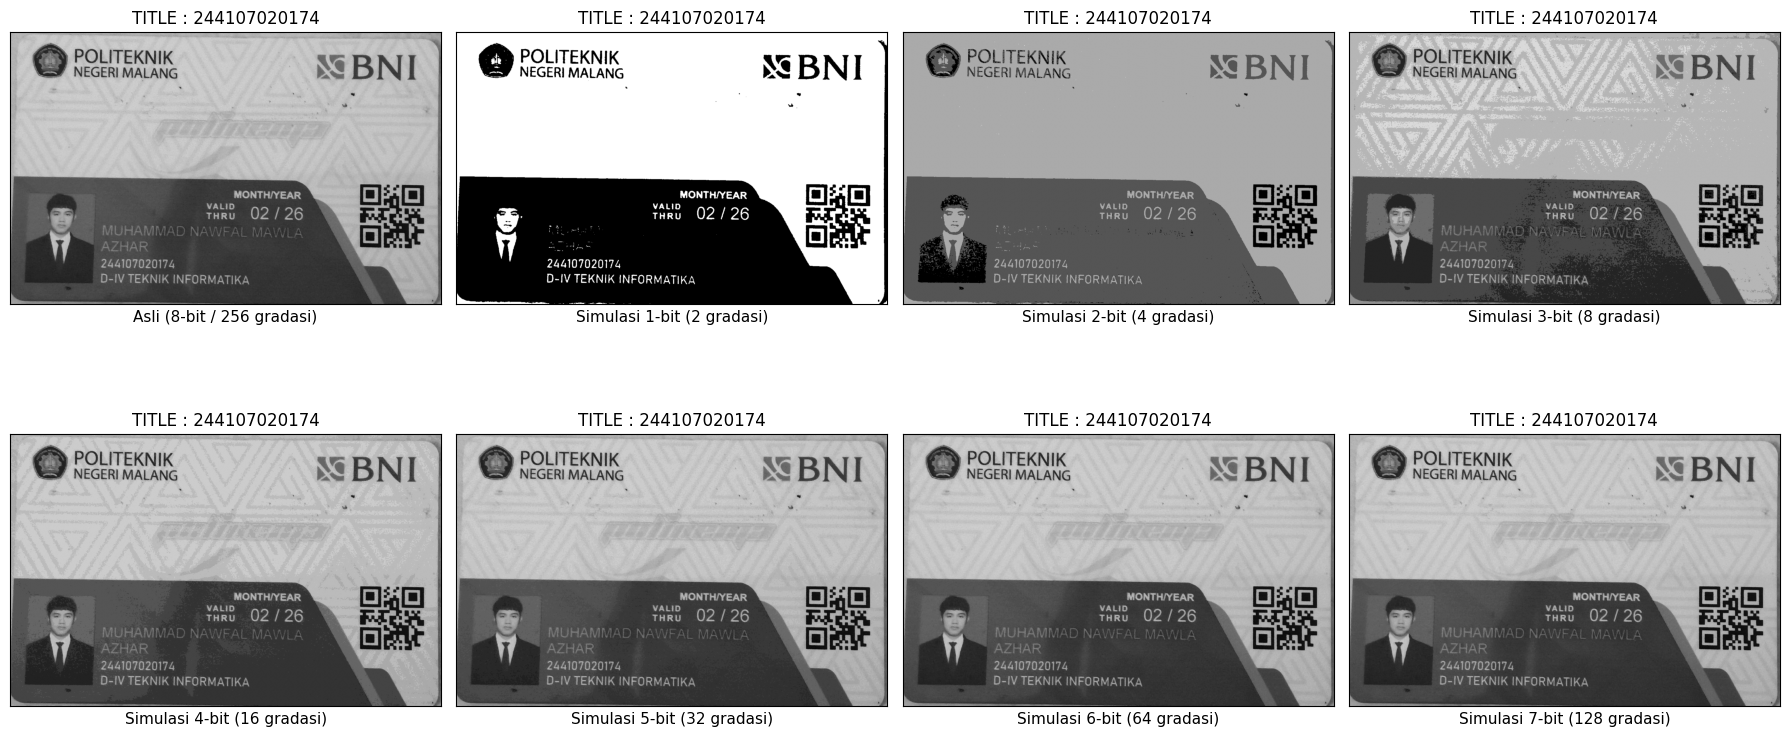

HASIL ANALISA TUGAS 7:
Kedalaman bit di mana nama dan NIM mulai masih terbaca:
Jawaban:
- Pada 1-bit dan 2-bit, gambar hancur menjadi bercak hitam-putih ekstrim
  (posterisasi tingkat tinggi) sehingga teks sama sekali tidak terbaca.
- Teks mulai bisa diidentifikasi dan dibaca samar-samar pada kedalaman 3-bit,
  dan semakin jelas pada 4-bit (16 gradasi warna abu-abu), karena kontras
  antara tinta tulisan dan latar belakang kartu mulai terbentuk kembali.


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_ktm1b = base_path + 'KTM1_b.jpeg'

#Baca citra langsung dalam mode Grayscale
img_ktm1b_gray = cv.imread(path_ktm1b, cv.IMREAD_GRAYSCALE)

#Siapkan kanvas plot (2 baris, 4 kolom) untuk 8 gambar
plt.figure(figsize=(18, 9))

#Tampilkan Gambar Asli (8-bit) di urutan pertama
plt.subplot(2, 4, 1)
plt.imshow(img_ktm1b_gray, cmap='gray', vmin=0, vmax=255)
plt.title(f"TITLE : {NIM}")
plt.xlabel("Asli (8-bit / 256 gradasi)", fontsize=11)
plt.xticks([]); plt.yticks([])

#Looping untuk simulasi bit depth dari 1 sampai 7
for bit_depth in range(1, 8):
    # Rumus modul: level = 255 / (2^bit_depth - 1)
    level = 255.0 / ((2 ** bit_depth) - 1)

    # Kuantisasi: warna baru = round(warna asli / level) * level
    depth_image = np.round(img_ktm1b_gray / level) * level
    depth_image = depth_image.astype(np.uint8)

    # Plot hasil ke sub-grid berikutnya
    plt.subplot(2, 4, bit_depth + 1)
    plt.imshow(depth_image, cmap='gray', vmin=0, vmax=255)
    plt.title(f"TITLE : {NIM}")

    # Hitung jumlah kemungkinan warna (2 pangkat bit_depth)
    jml_warna = 2 ** bit_depth
    plt.xlabel(f"Simulasi {bit_depth}-bit ({jml_warna} gradasi)", fontsize=11)
    plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

# 5. Cetak Analisa
print("="*75)
print("HASIL ANALISA TUGAS 7:")
print("="*75)
print("Kedalaman bit di mana nama dan NIM mulai masih terbaca:")
print("Jawaban:")
print("- Pada 1-bit dan 2-bit, gambar hancur menjadi bercak hitam-putih ekstrim")
print("  (posterisasi tingkat tinggi) sehingga teks sama sekali tidak terbaca.")
print("- Teks mulai bisa diidentifikasi dan dibaca samar-samar pada kedalaman 3-bit,")
print("  dan semakin jelas pada 4-bit (16 gradasi warna abu-abu), karena kontras")
print("  antara tinta tulisan dan latar belakang kartu mulai terbentuk kembali.")
print("="*75)

Total citra noise yang berhasil dibaca: 100 foto



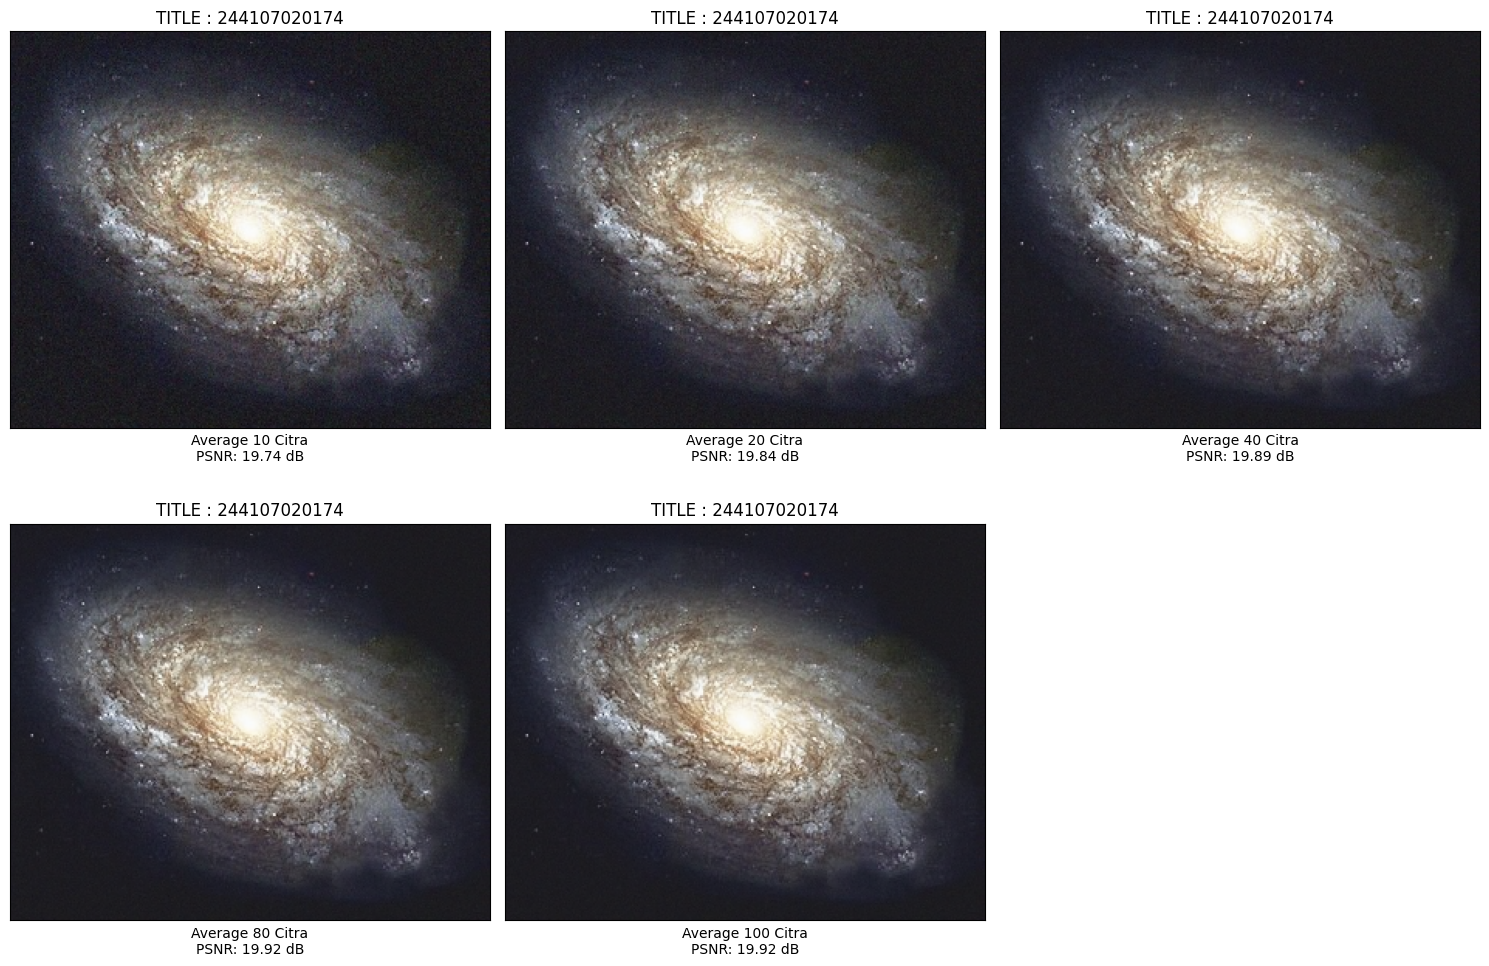

HASIL ANALISA TUGAS 8 (TABEL PSNR):
No    | Jumlah Citra di Average   | Nilai PSNR (dB)     
-------------------------------------------------------
1     | 10                        | 19.7363
2     | 20                        | 19.8413
3     | 40                        | 19.8912
4     | 80                        | 19.9181
5     | 100                       | 19.9220

KESIMPULAN:
1. Peningkatan jumlah citra pada awalnya (10 ke 40) memberikan lonjakan PSNR
   yang signifikan karena noise acak dengan cepat saling menetralkan.
2. Setelah menyentuh angka 40-80 citra, peningkatannya mulai tidak signifikan
   (kurva landai) karena batas efektif merata-rata noise Gaussian telah tercapai.


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt


base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_asli = base_path + 'galaxy.jpg'
path_noises = base_path + 'noises/*.jpg'

#Fungsi Perhitungan PSNR
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

#Baca citra asli sebagai patokan kebersihan gambar
img_asli = cv.imread(path_asli)

#Baca semua citra noise menggunakan glob dan masukkan ke list
cv_img = []
for img_path in glob.glob(path_noises):
    img = cv.imread(img_path)
    if img is not None:
        cv_img.append(img)

print(f"Total citra noise yang berhasil dibaca: {len(cv_img)} foto\n")

#Proses Averaging dan Hitung PSNR jika gambar tersedia
if img_asli is not None and len(cv_img) > 0:
    daftar_uji = [10, 20, 40, 80, 100]
    hasil_psnr = []

    plt.figure(figsize=(15, 10))

    for i, jumlah in enumerate(daftar_uji):
        # Ambil subset gambar sesuai skenario jumlah
        subset_img = cv_img[:jumlah]

        # Buat kanvas kosong float64 untuk menampung total penjumlahan
        avg_img = np.zeros(img_asli.shape, np.float64)

        # Tambahkan semua matriks piksel
        for img in subset_img:
            avg_img += img

        # Bagi dengan jumlah gambar (Hitung rata-rata)
        avg_img /= jumlah
        avg_img = np.clip(avg_img, 0, 255).astype(np.uint8)

        # Evaluasi PSNR
        nilai_psnr = PSNR(img_asli, avg_img)
        hasil_psnr.append(nilai_psnr)

        # Tampilkan
        plt.subplot(2, 3, i + 1)
        plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
        plt.title(f"TITLE : {NIM}")
        plt.xlabel(f"Average {jumlah} Citra\nPSNR: {nilai_psnr:.2f} dB")
        plt.xticks([]); plt.yticks([])

    plt.tight_layout()
    plt.show()

    #Cetak Tabel dan Analisa
    print("="*75)
    print("HASIL ANALISA TUGAS 8 (TABEL PSNR):")
    print("="*75)
    print(f"{'No':<5} | {'Jumlah Citra di Average':<25} | {'Nilai PSNR (dB)':<20}")
    print("-" * 55)
    for i, jumlah in enumerate(daftar_uji):
        print(f"{i+1:<5} | {jumlah:<25} | {hasil_psnr[i]:.4f}")
    print("\nKESIMPULAN:")
    print("1. Peningkatan jumlah citra pada awalnya (10 ke 40) memberikan lonjakan PSNR")
    print("   yang signifikan karena noise acak dengan cepat saling menetralkan.")
    print("2. Setelah menyentuh angka 40-80 citra, peningkatannya mulai tidak signifikan")
    print("   (kurva landai) karena batas efektif merata-rata noise Gaussian telah tercapai.")
    print("="*75)
else:
    print("GAGAL: File galaxy.jpg atau isi folder noises tidak terbaca.")

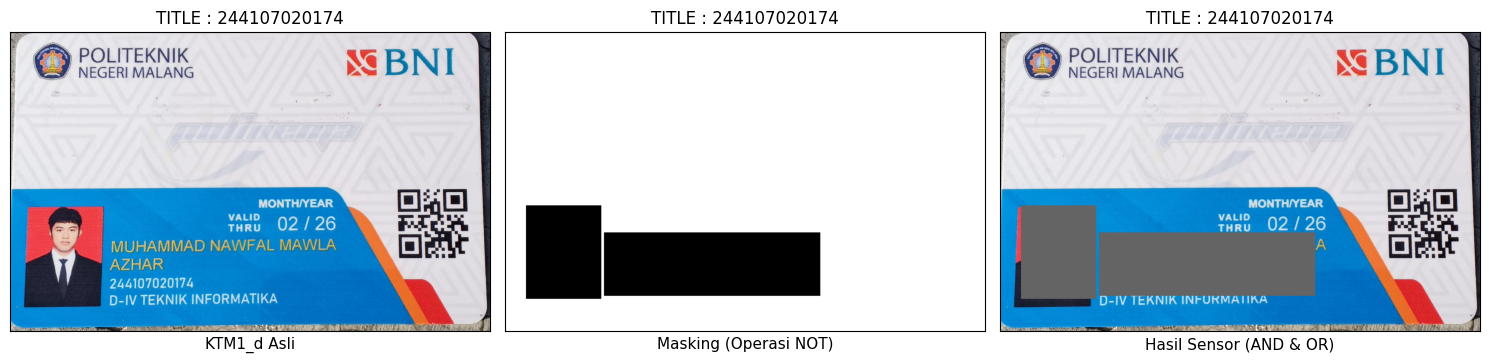

HASIL ANALISA TUGAS 9:
Pembuatan Sensor Privasi dengan Operasi Biner:
1. Operasi NOT (bitwise_not): Membalikkan area mask (hitam jadi putih).
2. Operasi AND (bitwise_and): Digunakan dua kali; pertama untuk 'melubangi'
   gambar asli pada koordinat wajah, dan kedua untuk memotong balok
   abu-abu agar ukurannya pas dengan lubang tersebut.
3. Operasi OR (bitwise_or): Bertindak sebagai 'lem' digital untuk
   menyatukan background yang berlubang dengan foreground balok abu-abu.


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_ktmd = base_path + 'KTM1_d.jpeg'

#  konversi ke RGB
img_ktmd = cv.imread(path_ktmd)
img_rgb = cv.cvtColor(img_ktmd, cv.COLOR_BGR2RGB)

#Buat Kanvas Masking Hitam Polos
mask = np.zeros(img_rgb.shape[:2], dtype=np.uint8)

# =========================================================================
# TENTUKAN KOORDINAT KOTAK SENSOR (Berdasarkan Penggaris Matplotlib)
# =========================================================================
# Kotak 1: Area Wajah (x, y, width, height)
x1, y1, w1, h1 = 70, 580, 250, 310
cv.rectangle(mask, (x1, y1), (x1+w1, y1+h1), 255, -1)

# Area Identitas / Nama & NIM (x, y, width, height)
x2, y2, w2, h2 = 330, 670, 720, 210
cv.rectangle(mask, (x2, y2), (x2+w2, y2+h2), 255, -1)

#Operasi Aljabar Biner
# A. NOT: Membalikkan mask
mask_inv = cv.bitwise_not(mask)

# B. AND: Melubangi gambar asli di area sensor
img_bg = cv.bitwise_and(img_rgb, img_rgb, mask=mask_inv)

#Buat warna sensor (Abu-abu: R=100, G=100, B=100)
sensor_color = np.full(img_rgb.shape, (100, 100, 100), dtype=np.uint8)

# C. AND: Mencetak balok warna abu-abu sesuai mask
img_fg = cv.bitwise_and(sensor_color, sensor_color, mask=mask)

# D. OR: Menggabungkan gambar berlubang dengan kotak abu-abu
img_final = cv.bitwise_or(img_bg, img_fg)

#Tampilkan Hasil
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("KTM1_d Asli", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(mask_inv, cmap='gray')
plt.title(f"TITLE : {NIM}")
plt.xlabel("Masking (Operasi NOT)", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(img_final)
plt.title(f"TITLE : {NIM}")
plt.xlabel("Hasil Sensor (AND & OR)", fontsize=11)
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

#Cetak Analisa
print("="*75)
print("HASIL ANALISA TUGAS 9:")
print("="*75)
print("Pembuatan Sensor Privasi dengan Operasi Biner:")
print("1. Operasi NOT (bitwise_not): Membalikkan area mask (hitam jadi putih).")
print("2. Operasi AND (bitwise_and): Digunakan dua kali; pertama untuk 'melubangi'")
print("   gambar asli pada koordinat wajah, dan kedua untuk memotong balok")
print("   abu-abu agar ukurannya pas dengan lubang tersebut.")
print("3. Operasi OR (bitwise_or): Bertindak sebagai 'lem' digital untuk")
print("   menyatukan background yang berlubang dengan foreground balok abu-abu.")
print("="*75)

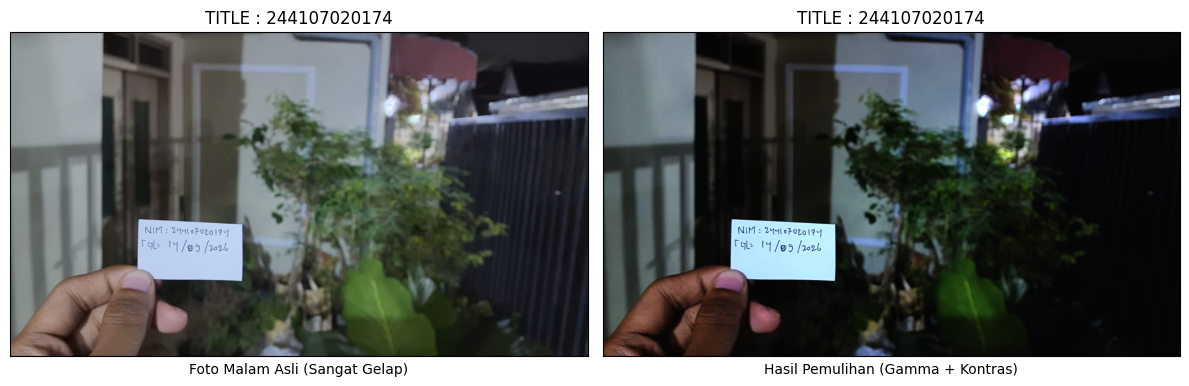

HASIL ANALISA TUGAS 10:
Kombinasi metode yang digunakan untuk memulihkan visibilitas:
1. Gamma Correction (Menggunakan nilai Gamma = 0.4):
   Sangat efektif untuk foto malam karena dapat mengangkat intensitas piksel
   di area bayangan (shadows) secara eksponensial. Ini membuat objek yang
   gelap menjadi terlihat tanpa membuat sumber cahaya terang menjadi clipping.

2. Transformasi Kontras Linier (a = 1.2, b = 5):
   Setelah diangkat dengan Gamma, gambar malam seringkali terlihat berkabut atau pudar.
   Pengali kontras (a > 1) disuntikkan untuk mengembalikan ketegasan batas antar objek
   dan mengembalikan ketajaman warna keseluruhan.


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


base_path = '/content/drive/MyDrive/Pcvdk_Nawfal/'
path_night = base_path + 'Pemandangan_malam.jpeg'

img_night = cv.imread(path_night)
img_night_rgb = cv.cvtColor(img_night, cv.COLOR_BGR2RGB)

#Tahap 1: Gamma Correction (Mencerahkan bayangan gelap)
# Nilai gamma 0.4 atau 0.5 biasanya sangat pas untuk foto malam
gamma = 0.4
inv_gamma = 1.0 / gamma
img_gamma = np.clip(255.0 * np.power(img_night_rgb / 255.0, inv_gamma), 0, 255).astype(np.uint8)

# Tahap 2: Transformasi Kontras (Menajamkan hasil cerah)
# Menggunakan rumus g(x,y) = a * f(x,y) + b
a = 1.5 # Sedikit dinaikkan kontrasnya
b = 5   # Sedikit tambahan brightness merata
img_final = np.clip(img_gamma.astype(np.float32) * a + b, 0, 255).astype(np.uint8)

#Tampilkan Perbandingan Hasil
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_night_rgb)
plt.title(f"TITLE : {NIM}")
plt.xlabel("Foto Malam Asli (Sangat Gelap)")
plt.xticks([]); plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(img_final)
plt.title(f"TITLE : {NIM}")
plt.xlabel("Hasil Pemulihan (Gamma + Kontras)")
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

# Cetak Analisa
print("="*75)
print("HASIL ANALISA TUGAS 10:")
print("="*75)
print("Kombinasi metode yang digunakan untuk memulihkan visibilitas:")
print("1. Gamma Correction (Menggunakan nilai Gamma = 0.4):")
print("   Sangat efektif untuk foto malam karena dapat mengangkat intensitas piksel")
print("   di area bayangan (shadows) secara eksponensial. Ini membuat objek yang")
print("   gelap menjadi terlihat tanpa membuat sumber cahaya terang menjadi clipping.")
print("\n2. Transformasi Kontras Linier (a = 1.2, b = 5):")
print("   Setelah diangkat dengan Gamma, gambar malam seringkali terlihat berkabut atau pudar.")
print("   Pengali kontras (a > 1) disuntikkan untuk mengembalikan ketegasan batas antar objek")
print("   dan mengembalikan ketajaman warna keseluruhan.")
print("="*75)